## CARD: Training Session 6

### Modeling a transient polytropic PFR

#### Example 1: Species and mass conservation in a PFR

**Implementation**:

- [NumPy](https://numpy.org/) for math and matrix operations
- [casADi](https://web.casadi.org/) to solve the DAE
- [Matplotlib](https://matplotlib.org/) with the module [pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to visualize the results

In [ ]:
import casadi as casADi
import matplotlib.pyplot as plt
import numpy as np


Defining values of constant parameters:

In [2]:
R = 8.314               # [J/Kmol]
Mw_i = np.array([2, 1]) # [kg/mol]    # 0: A, 1: B
T = 300                 # [K]
p = 1e5                 # [Pa]
c_f = p / (R * T)       # [mol/m^3]
k = 0.25                # [1/s]
nu = np.array([-1, 2])  # [-]
L = 2                   # [m]
u_in = 0.1              # [m/s]

Using an array as upper bound of the integral to calculate various timesteps:

In [3]:
t_0 = 0         # [s]
t_steps = 101   # [-]
t_end = 20      # [s]
t_i = np.linspace(t_0, t_end, t_steps)

Setting the values and vector for the axial discretization:

In [4]:
n_axial = 200
delta_z = 1 / n_axial
z_c = np.linspace(0 + delta_z / 2, 1 - delta_z / 2, n_axial)

Now setting the initial and boundary conditions:

In [5]:
w_i_0 = np.array([1, 0])    # [-]   # 0: A, 1: B
w_i_in = np.array([1, 0])   # [-]   # 0: A, 1: B

Defining necessary differential and algebraic symbolic variables:

In [6]:
w_i = casADi.SX.sym("w_i", (n_axial, 2))    # [-]   # 0: A, 1: B
u = casADi.SX.sym("u", n_axial)             # [m/s]

Defining all other variables ($\rho$, $M_w$, $c_i$) implicitly as function of $𝑤_i$:

In [7]:
def f_Mw(w_i):
    unity = casADi.DM.ones(len(Mw_i))
    Mw = 1 / (casADi.dot(w_i / casADi.SX((Mw_i)), unity))
    return Mw


def f_rho(w_i):
    rho = c_f * f_Mw(w_i)
    return rho


def f_ci(w_i):
    c_i = w_i * f_Mw(w_i) / Mw_i * c_f
    return c_i

Define the algebraic equation for the mass conservation:

In [8]:
ae = casADi.SX.sym("ae", n_axial)
for z in range(n_axial):
    ae[z] = u[z] - u_in * f_rho(w_i_in) / f_rho(w_i[z, :].T)

Define the differential equation for species conservation without the boundary:

In [9]:
ode = casADi.SX.sym("ode", (n_axial, 2))
for comp in range(len(nu)):
    for z in range(1, n_axial):
        ode[z, comp] = (
            -(w_i[z, comp] - w_i[z - 1, comp]) * u[z] / (L * delta_z) + 
            Mw_i[comp] / f_rho(w_i[z, :].T) * nu[comp] * f_ci(w_i[z, :].T)[0] * k
            )

Define the differential equation at the boundary:

In [10]:
z = 0
for comp in range(len(nu)):
    ode[z, comp] = (
        -(w_i[z, comp] - w_i_in[comp]) * u[z] / (L * delta_z) + 
        Mw_i[comp] / f_rho(w_i[z, :].T) * nu[comp] * f_ci(w_i[z, :].T)[0] * k
        )

Reshape 2D arrays into 1D vector needed for DAE solver:

In [11]:
w_i_reshaped = casADi.reshape(w_i, n_axial * len(nu), 1)
ode_reshaped = casADi.reshape(ode, n_axial * len(nu), 1)

Next a casADi specific dictionary is created with the following entries:

In [12]:
dae = {}
dae["x"] = w_i_reshaped
dae["z"] = u
dae["ode"] = ode_reshaped
dae["alg"] = ae

Then define and call the integrator to solve the DAE:

In [13]:
I = casADi.integrator("I", "idas", dae, t_0, t_i)
w_i_0_reshaped = np.zeros(n_axial * len(nu))
w_i_0_reshaped[0:n_axial] = w_i_0[0]
w_i_0_reshaped[n_axial:] = w_i_0[1]
res_dic = I(x0=w_i_0_reshaped)

Results need to be reshaped like this:

In [14]:
w_i_res = np.empty(shape=(n_axial, t_steps, len(nu)))
res_x = res_dic["xf"].full()
for t in range(t_steps):
    for comp in range(len(nu)):
        w_i_res[:, t, comp] = res_x[comp * n_axial : n_axial * (comp + 1), t]
u_res = res_dic["zf"].full()

Plot the results:

Text(0.5, 0, '$z/L$')

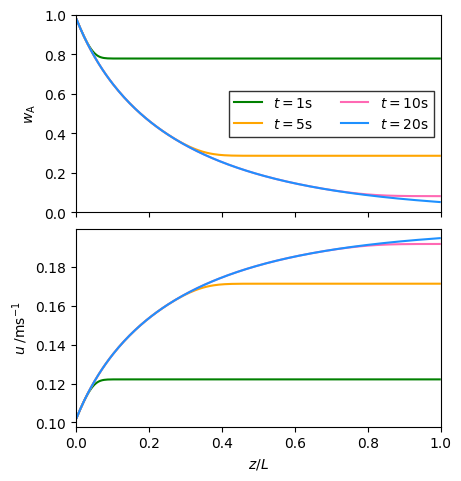

In [15]:
# Create figure and axes of plot
fig, axs = plt.subplots(2, 1, figsize=(4.5, 4.7), constrained_layout=True, sharex=True)

# Plot values
axs[0].plot(z_c, w_i_res[:, 5, 0], color="green", label="$t= 1 \\mathregular{s}$")
axs[0].plot(z_c, w_i_res[:, 25, 0], color="orange", label="$t= 5 \\mathregular{s}$")
axs[0].plot(z_c, w_i_res[:, 50, 0], color="hotpink", label="$t= 10 \\mathregular{s}$")
axs[0].plot(z_c, w_i_res[:, 100, 0], color="dodgerblue", label="$t= 20 \\mathregular{s}$")

axs[1].plot(z_c, u_res[:, 5], color="green")
axs[1].plot(z_c, u_res[:, 25], color="orange")
axs[1].plot(z_c, u_res[:, 50], color="hotpink")
axs[1].plot(z_c, u_res[:, 100], color="dodgerblue")

# Set axes parameters
axs[0].set_xlim(0, 1)
axs[0].set_ylim(0, 1)
axs[0].set_ylabel("$w_{\\mathregular{A}}$")
axs[0].legend(fancybox=False, loc="best", ncol=2, edgecolor="black")

axs[1].set_ylabel("$u \\; \\mathregular{/ms^{-1}}$")
axs[1].set_xlabel("$z/L$")

#### Example 2: Energy and mass conservation in a PFR

**Implementation**:

- [NumPy](https://numpy.org/) for math and matrix operations
- [casADi](https://web.casadi.org/) to solve the DAE
- [Matplotlib](https://matplotlib.org/) with the module [pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to visualize the results

In [ ]:
import casadi as casADi
import matplotlib.pyplot as plt
import numpy as np


Defining values of constant parameters:

In [17]:
R = 8.314       # [J/(K mol)]
Mw = 1          # [kg/mol]
U = 100         # [W/(m^2 K)]
T_wall = 350    # [K]
p = 1e5         # [Pa]
r = 100         # [mol/(s m^3)]
delta_H = -1000 # [J/mol]
L = 2           # [m]
D = 20e-3       # [m]
u_in = 0.1      # [m/s]
cp = 2000       # [J/(kg K)]

Using an array as upper bound of the integral to calculate various timesteps:

In [18]:
t_0 = 0         # [s]
t_steps = 101   # [-]
t_end = 20      # [s]
t_i = np.linspace(t_0, t_end, t_steps)

Setting the values and vector for the axial discretization.

In [19]:
n_axial = 200
delta_z = 1 / n_axial
z_c = np.linspace(0 + delta_z / 2, 1 - delta_z / 2, n_axial)

Now setting the initial and boundary conditions:

In [20]:
T_0 = 300   # [K]
T_in = 300  # [K]

Defining necessary differential and algebraic symbolic variables:

In [21]:
T = casADi.SX.sym("T", n_axial)  # differential # [K]
u = casADi.SX.sym("u", n_axial)  # algebraic    # [m/s]

Defining all other variables ($\rho$, $c_f$) implicitly as function of $T$:

In [22]:
def f_cf(T):
    cf = p / (R * T)
    return cf


def f_rho(T):
    rho = f_cf(T) * Mw
    return rho

Define the algebraic equation for the mass conservation:

In [23]:
ae = casADi.SX.sym("ae", n_axial)
for z in range(n_axial):
    ae[z] = u[z] - u_in * f_rho(T_in) / f_rho(T[z])

Define the differential equation for energy conservation without the boundary:

In [24]:
ode = casADi.SX.sym("ode", n_axial)
for z in range(1, n_axial):
    ode[z] = (
        -(T[z] - T[z - 1]) * u[z] / (L * delta_z) + 
        1 / (cp * f_rho(T[z])) * (-4 * U / D * (T[z] - T_wall) + r * (-delta_H))
        )

Define the differential equation at the boundary:

In [25]:
z = 0
ode[z] = (
    -(T[z] - T_in) * u[z] / (L * delta_z) + 
    1 / (cp * f_rho(T[z])) * ( -4 * U / D * (T[z] - T_wall) + r * (-delta_H))
    )

Next a casADi specific dictionary is created with the following entries:

In [26]:
dae = {}
dae["x"] = T
dae["z"] = u
dae["ode"] = ode
dae["alg"] = ae

Then define and call the integrator to solve the DAE:

In [27]:
I = casADi.integrator("I", "idas", dae, t_0, t_i)
res_dic = I(x0=T_0)
T_res = res_dic["xf"].full()
u_res = res_dic["zf"].full()

Plot the results:

Text(0.5, 0, '$z/L$')

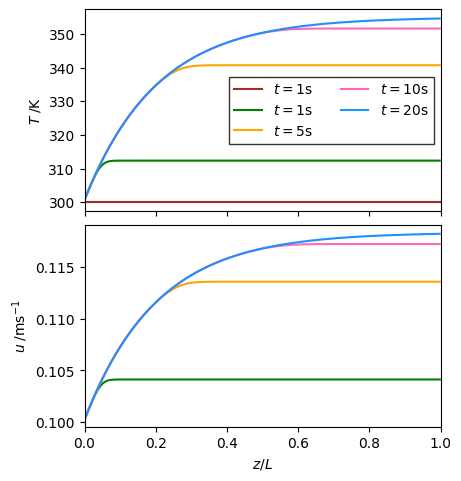

In [28]:
# Create figure and axes of plot
fig, axs = plt.subplots(2, 1, figsize=(4.5, 4.7), constrained_layout=True, sharex=True)

# Plot values
axs[0].plot(z_c, T_res[:, 0], color="brown", label="$t= 1 \\mathregular{s}$")
axs[0].plot(z_c, T_res[:, 5], color="green", label="$t= 1 \\mathregular{s}$")
axs[0].plot(z_c, T_res[:, 25], color="orange", label="$t= 5 \\mathregular{s}$")
axs[0].plot(z_c, T_res[:, 50], color="hotpink", label="$t= 10 \\mathregular{s}$")
axs[0].plot(z_c, T_res[:, 100], color="dodgerblue", label="$t= 20 \\mathregular{s}$")

axs[1].plot(z_c, u_res[:, 5], color="green")
axs[1].plot(z_c, u_res[:, 25], color="orange")
axs[1].plot(z_c, u_res[:, 50], color="hotpink")
axs[1].plot(z_c, u_res[:, 100], color="dodgerblue")

# Set axes parameters
axs[0].set_xlim(0, 1)
axs[0].set_ylabel("$T \\; \\mathregular{/K}$")
axs[0].legend(fancybox=False, loc="best", ncol=2, edgecolor="black")

axs[1].set_ylabel("$u \\; \\mathregular{/ms^{-1}}$")
axs[1].set_xlabel("$z/L$")
